STEP 1 — FOLDER TREE under /kaggle/input
DATASET ROOT: /kaggle/input/datasets
input/   [0 files | -]
  datasets/   [0 files | -]
    mantashamahi/   [0 files | -]
      pavecrack1300-a-uav-acquired-pavement-crack/   [0 files | -]
        PaveCrack1300 A UAV-Acquired Pavement Crack Segmen/   [2 files | .csv:1, .txt:1]

STEP 2 — README.txt (verbatim)
--- /kaggle/input/datasets/mantashamahi/pavecrack1300-a-uav-acquired-pavement-crack/PaveCrack1300 A UAV-Acquired Pavement Crack Segmen/README.txt ---
PaveCrack1300: A UAV-Acquired Pavement Crack Segmentation Dataset

Version : 1.0
Date    : April 2026
License : CC BY 4.0 (https://creativecommons.org/licenses/by/4.0/)
DOI     : 10.17632/8b27pdcv7.1


── OVERVIEW ─────────────────────────────────────────────────────────────────

PaveCrack1300 is a pixel-level annotated dataset of pavement surface cracks
acquired by an Unmanned Aerial Vehicle (UAV). The dataset contains 1,300
image–mask pairs cropped from high-resolution UAV aerial photographs 

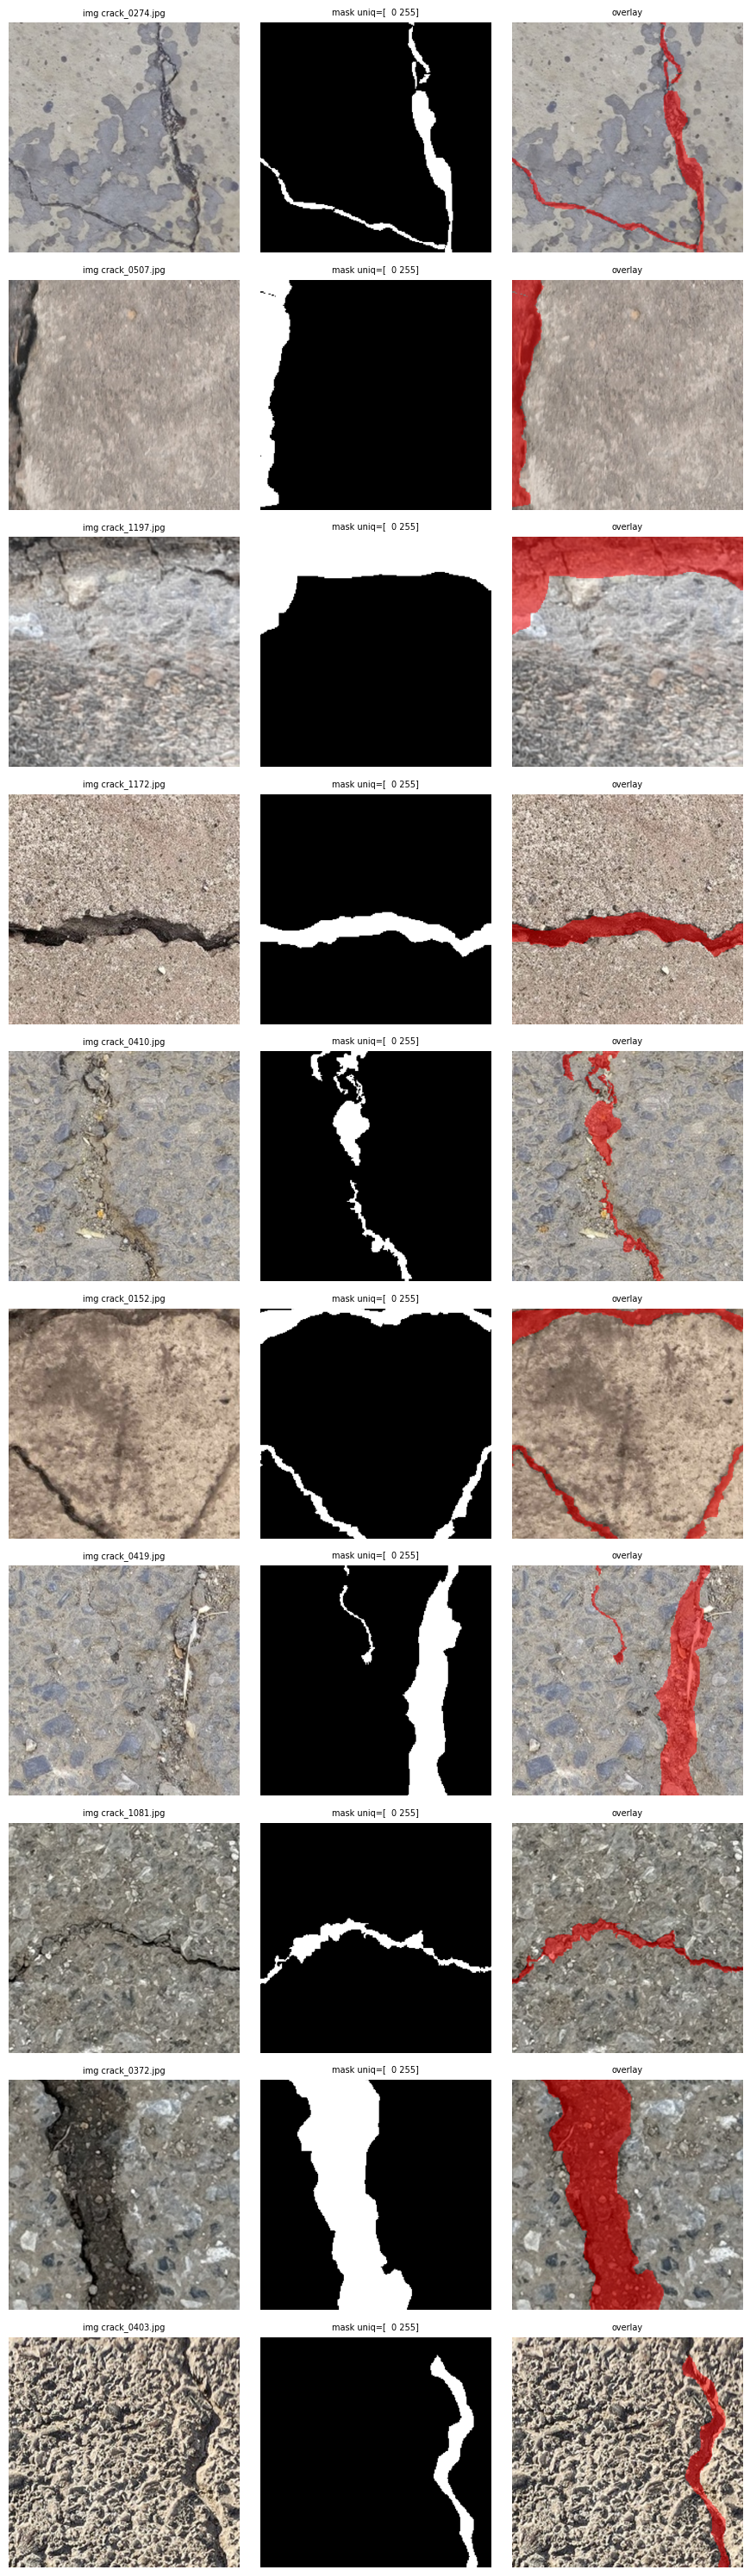


===== SUMMARY (copy this whole block back) =====
dataset_roots        : ['/kaggle/input/datasets']
n_paired             : 1300
n_unpaired_images    : 0
mask_pil_modes       : {'L': 60}
distinct_mask_values : [0, 255]
rgb_mask_colors      : []
n_classes_guess      : 2 (single-channel)
pixel_class_pct      : {0: 89.0173, 255: 10.9827}
resolutions_top       : {(512, 512): 200}
n_resolutions_seen    : 1
csv_files            : ['/kaggle/input/datasets/mantashamahi/pavecrack1300-a-uav-acquired-pavement-crack/PaveCrack1300 A UAV-Acquired Pavement Crack Segmen/sample_metadata.csv']
>>> ALSO tell me: which sample_metadata.csv column identifies the ORIGINAL
>>> source image / flight / capture (i.e. images that are crops of one photo)?
>>> That column becomes the leakage-safe GROUP KEY. If none exists, say so.


In [1]:
# =====================================================================
# PHASE-0 EDA PROBE  ·  PaveCrack1300 (UAV pavement crack segmentation)
# ---------------------------------------------------------------------
# Run this ONCE on Kaggle (CPU is fine, saves GPU quota) with the
# PaveCrack1300 dataset attached via "+ Add Input".
# It only READS the data. Copy the whole ===== SUMMARY ===== block back.
# Its purpose: pin down (1) folder tree, (2) image<->mask pairing,
# (3) mask encoding + #classes, (4) resolutions, (5) metadata columns,
# and (6) the GROUP KEY that makes the split leakage-safe.
# =====================================================================
import os, re, glob, json, warnings
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
warnings.filterwarnings("ignore")

try:
    from PIL import Image
except Exception:
    Image = None
import matplotlib.pyplot as plt

INPUT = Path("/kaggle/input")
IMG_EXT  = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

print("="*70); print("STEP 1 — FOLDER TREE under /kaggle/input"); print("="*70)
roots = [p for p in INPUT.iterdir() if p.is_dir()] if INPUT.exists() else []
for r in roots:
    print("DATASET ROOT:", r)
# print directory tree (dirs + file-count + extensions per dir), depth<=4
dir_stats = {}
for dp, dns, fns in os.walk(INPUT):
    depth = len(Path(dp).relative_to(INPUT).parts)
    if depth > 4:
        dns[:] = []
        continue
    exts = Counter(Path(f).suffix.lower() for f in fns)
    dir_stats[dp] = (len(fns), exts)
    indent = "  " * depth
    ext_str = ", ".join(f"{k}:{v}" for k, v in exts.most_common(6)) or "-"
    print(f"{indent}{Path(dp).name or dp}/   [{len(fns)} files | {ext_str}]")

print("\n" + "="*70); print("STEP 2 — README.txt (verbatim)"); print("="*70)
for rp in glob.glob(str(INPUT/"**"/"README*"), recursive=True):
    try:
        print(f"--- {rp} ---")
        print(Path(rp).read_text(errors="ignore")[:4000])
    except Exception as e:
        print("could not read", rp, e)

print("\n" + "="*70); print("STEP 3 — sample_metadata.csv  (THE GROUP-KEY CANDIDATE)"); print("="*70)
csvs = glob.glob(str(INPUT/"**"/"*.csv"), recursive=True)
try:
    import pandas as pd
    for cp in csvs:
        print(f"\n--- {cp} ---")
        df = pd.read_csv(cp)
        print("shape:", df.shape)
        print("columns:", list(df.columns))
        print("dtypes:\n", df.dtypes)
        print("\nhead(8):\n", df.head(8).to_string())
        print("\nper-column nunique (low nunique => candidate group key):")
        for c in df.columns:
            nun = df[c].nunique(dropna=False)
            print(f"   {c:<28} nunique={nun}")
            if 1 < nun <= 25:
                print("        value_counts:", dict(df[c].value_counts(dropna=False).head(25)))
except Exception as e:
    print("pandas/csv read issue:", e)

print("\n" + "="*70); print("STEP 4 — IMAGE vs MASK folders + pairing"); print("="*70)
# collect all image-like files grouped by parent dir
by_dir = defaultdict(list)
for p in INPUT.rglob("*"):
    if p.is_file() and p.suffix.lower() in IMG_EXT:
        by_dir[p.parent].append(p)
for d, files in sorted(by_dir.items(), key=lambda kv: -len(kv[1])):
    exts = Counter(f.suffix.lower() for f in files)
    print(f"{len(files):>6}  {d}   exts={dict(exts)}")
    print("        e.g.", [f.name for f in files[:4]])

# classify by EXACT basename token (NOT substring — avoids 'seg' in dataset name)
def role(path):
    parts = {x.lower() for x in path.parts}
    if "masks" in parts or "mask" in parts or "labels" in parts or "gt" in parts or "annotations" in parts:
        return "mask"
    if "images" in parts or "image" in parts or "img" in parts or "jpegimages" in parts:
        return "image"
    return "unknown"

img_files, mask_files = [], []
for d, files in by_dir.items():
    r = role(d)
    if r == "mask":  mask_files += files
    elif r == "image": img_files += files
    else:            img_files += files   # fall back: treat unknown as image
print(f"\nclassified: images={len(img_files)}  masks={len(mask_files)}")

def sig(p):  # integer signature for pairing
    return tuple(re.findall(r"\d+", p.stem))
mask_by_sig = defaultdict(list)
for m in mask_files: mask_by_sig[sig(m)].append(m)
paired, unpaired = [], []
for im in img_files:
    ms = mask_by_sig.get(sig(im), [])
    (paired if ms else unpaired).append((im, ms[0] if ms else None))
print(f"paired={len(paired)}  unpaired_images={len(unpaired)}")
if unpaired[:3]:
    print("unpaired examples:", [str(u[0].name) for u in unpaired[:3]])
if paired[:3]:
    print("pair examples:")
    for im, mk in paired[:3]:
        print("   IMG:", im.name, "  <->  MASK:", mk.name)

print("\n" + "="*70); print("STEP 5 — MASK ENCODING + PIXEL-CLASS DISTRIBUTION"); print("="*70)
uniq_all = Counter()
px_by_val = Counter()
sample_masks = [mk for _, mk in paired if mk is not None][:60]
mask_modes = Counter()
for mk in sample_masks:
    try:
        arr = np.array(Image.open(mk))
        mask_modes[str(Image.open(mk).mode)] += 1
        if arr.ndim == 3:            # RGB-coded?
            arr2 = arr.reshape(-1, arr.shape[-1])
            for row in np.unique(arr2, axis=0)[:20]:
                uniq_all[tuple(int(x) for x in row)] += 1
        else:
            vals, cnts = np.unique(arr, return_counts=True)
            for v, c in zip(vals, cnts):
                uniq_all[int(v)] += 1
                px_by_val[int(v)] += int(c)
    except Exception as e:
        print("mask read err", mk, e)
print("mask PIL modes:", dict(mask_modes))
print("distinct mask values seen (value -> #masks containing it):")
for v, c in sorted(uniq_all.items(), key=lambda kv: (isinstance(kv[0], tuple), kv[0])):
    print(f"   {v}: in {c} masks")
if px_by_val:
    tot = sum(px_by_val.values())
    print("\nPIXEL-LEVEL class distribution (single-channel masks):")
    for v, c in sorted(px_by_val.items()):
        print(f"   value {v:>3}: {c:>12,} px  ({100*c/tot:6.3f}%)")

print("\n" + "="*70); print("STEP 6 — IMAGE RESOLUTIONS"); print("="*70)
sizes = Counter()
for im, _ in paired[:200]:
    try:
        w, h = Image.open(im).size
        sizes[(w, h)] += 1
    except Exception:
        pass
print("resolution (W,H) -> count  [first 200 imgs]:")
for s, c in sizes.most_common(12):
    print(f"   {s}: {c}")

print("\n" + "="*70); print("STEP 7 — 10 IMAGE|MASK|OVERLAY previews"); print("="*70)
show = [(im, mk) for im, mk in paired if mk is not None][:10]
if show:
    fig, ax = plt.subplots(len(show), 3, figsize=(9, 3*len(show)))
    ax = np.atleast_2d(ax)
    for i, (im, mk) in enumerate(show):
        I = np.array(Image.open(im).convert("RGB"))
        M = np.array(Image.open(mk))
        Mv = M if M.ndim == 2 else M[..., 0]
        ax[i,0].imshow(I);                 ax[i,0].set_title(f"img {im.name}", fontsize=7)
        ax[i,1].imshow(Mv, cmap="gray");   ax[i,1].set_title(f"mask uniq={np.unique(Mv)[:6]}", fontsize=7)
        ov = I.copy()
        m = (Mv > 0)
        if ov.shape[:2] == m.shape:
            ov[m] = (0.5*ov[m] + np.array([255,0,0])*0.5).astype(np.uint8)
        ax[i,2].imshow(ov);                ax[i,2].set_title("overlay", fontsize=7)
        for a in ax[i]: a.axis("off")
    plt.tight_layout(); plt.savefig("probe_overlays.png", dpi=90); plt.show()

print("\n" + "="*70); print("===== SUMMARY (copy this whole block back) ====="); print("="*70)
print(f"dataset_roots        : {[str(r) for r in roots]}")
print(f"n_paired             : {len(paired)}")
print(f"n_unpaired_images    : {len(unpaired)}")
print(f"mask_pil_modes       : {dict(mask_modes)}")
print(f"distinct_mask_values : {sorted([v for v in uniq_all if not isinstance(v, tuple)])}")
print(f"rgb_mask_colors      : {[v for v in uniq_all if isinstance(v, tuple)][:12]}")
print(f"n_classes_guess      : {len([v for v in uniq_all if not isinstance(v, tuple)])} (single-channel)")
if px_by_val:
    tot = sum(px_by_val.values())
    print(f"pixel_class_pct      : { {v: round(100*c/tot,4) for v,c in sorted(px_by_val.items())} }")
print(f"resolutions_top       : {dict(sizes.most_common(5))}")
print(f"n_resolutions_seen    : {len(sizes)}")
print("csv_files            :", csvs)
print("="*70)
print(">>> ALSO tell me: which sample_metadata.csv column identifies the ORIGINAL")
print(">>> source image / flight / capture (i.e. images that are crops of one photo)?")
print(">>> That column becomes the leakage-safe GROUP KEY. If none exists, say so.")
